In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LogNorm

import glob
#from astropy.io import fits
#from regions import SkyRegion, PixCoord, CirclePixelRegion, EllipsePixelRegion, EllipseAnnulusPixelRegion, EllipseSkyRegion, RectanglePixelRegion, PixCoord

#from astropy.coordinates import SkyCoord


#from astropy.coordinates import Angle
#from astropy import units as u

#from photutils.detection import DAOStarFinder
#from photutils.aperture import CircularAperture
#from astropy.modeling import models, fitting

import sys, os
sys.path.append(os.path.expanduser('~/Desktop/Pangal'))

from pangal.pangal import PanGal
#from pangal.pfitter import PFitter
from pangal.region import Region, Contours, Point
from pangal.photometry_table import PhotometryTable



#from pangal.model_builders.boissier import M, Md, Rd, Sigma_0, surface_density, Vc_to_Md, Md_to_Vc, Rc, rho_0, velocity_profile, boissier_unperturbed, boissier_quenched

import warnings
warnings.simplefilter("ignore")


In [2]:
directory = '/home/utente/Desktop/Jellifish/DATA/Coma/NGC4848/FITS_OBS/'


muse_file =  glob.glob(directory+'*muse*.fits')
spitzer_files = glob.glob(directory+'*SPITZER_*.fits')
sdss_files = glob.glob(directory+'*sdss*.fits')
wise_files = glob.glob(directory+'*WISE*.fits')
hershel_files = glob.glob(directory+'*hpacs*.fits')
twomass_files = glob.glob(directory+'*2mass*.fits')
hst_files = glob.glob(directory+'*hst*.fits')
galex_files = ['/home/utente/Desktop/Jellifish/DATA/Coma/galex_Coma_coadd-int_nuv.fits','/home/utente/Desktop/Jellifish/DATA/Coma/galex_Coma_coadd-int_fuv.fits']

files_list = galex_files + muse_file + sdss_files + twomass_files + spitzer_files + hershel_files #+hst_files + wise_files 



In [3]:
#print(files_list)

In [4]:
z_true =  0.023974 
ra_center, dec_center = 194.523241, 28.242570

distance = 104 # Mpc

M_star = 10**10.32
#V = Md_to_Vc(M_star)

#print(V)
#spin = 0.05
#print(Rd(V,spin))

# Convert angular scale to physical scale
from astropy.cosmology import Planck18 as cosmo
z_Coma = 0.023513
D_A = cosmo.angular_diameter_distance(z_Coma).to('pc').value

theta_deg_1kpc = 1e3 / D_A / (np.pi / 180)               # Convert 1 kpc in deg
theta_arcsec_1kpc = 1e3 / D_A / (np.pi / 648000)         # Convert 1 kpc in arcsec



In [5]:
galaxy = PanGal(fits_files=files_list,target_coords = [ra_center,dec_center],fov=1/12,EBmV=0.0093,EBmV_err=0.0002)


Processing GALEX file:  /home/utente/Desktop/Jellifish/DATA/Coma/galex_Coma_coadd-int_nuv.fits
Processing GALEX file:  /home/utente/Desktop/Jellifish/DATA/Coma/galex_Coma_coadd-int_fuv.fits
Processing MUSE:  /home/utente/Desktop/Jellifish/DATA/Coma/NGC4848/FITS_OBS/NGC4848_muse_cut.fits
Processing SDSS file:  /home/utente/Desktop/Jellifish/DATA/Coma/NGC4848/FITS_OBS/sdss_u.fits
Processing SDSS file:  /home/utente/Desktop/Jellifish/DATA/Coma/NGC4848/FITS_OBS/sdss_i.fits
Processing SDSS file:  /home/utente/Desktop/Jellifish/DATA/Coma/NGC4848/FITS_OBS/sdss_g.fits
Processing SDSS file:  /home/utente/Desktop/Jellifish/DATA/Coma/NGC4848/FITS_OBS/sdss_r.fits
Processing SDSS file:  /home/utente/Desktop/Jellifish/DATA/Coma/NGC4848/FITS_OBS/sdss_z.fits
Processing 2MASS:  /home/utente/Desktop/Jellifish/DATA/Coma/NGC4848/FITS_OBS/2mass_H.fits
Processing 2MASS:  /home/utente/Desktop/Jellifish/DATA/Coma/NGC4848/FITS_OBS/2mass_K.fits
Processing 2MASS:  /home/utente/Desktop/Jellifish/DATA/Coma/NGC4848

In [6]:
galaxy.overview

Images: 

['galex_nuv', 'galex_fuv', 'muse_blue', 'muse_green', 'muse_red', 'muse_nir', 'muse_white_aoe', 'sdss_u', 'sdss_i', 'sdss_g', 'sdss_r', 'sdss_z', '2mass_h', '2mass_ks', '2mass_j', 'spitzer_irac_2', 'spitzer_irac_3', 'spitzer_irac_4', 'spitzer_irac_1', 'herschel_pacs_70um', 'herschel_pacs_160um', 'herschel_pacs_100um']

Cubes: 

['muse']


KeyError: 'hst_wfc3_uvis_f350lp'

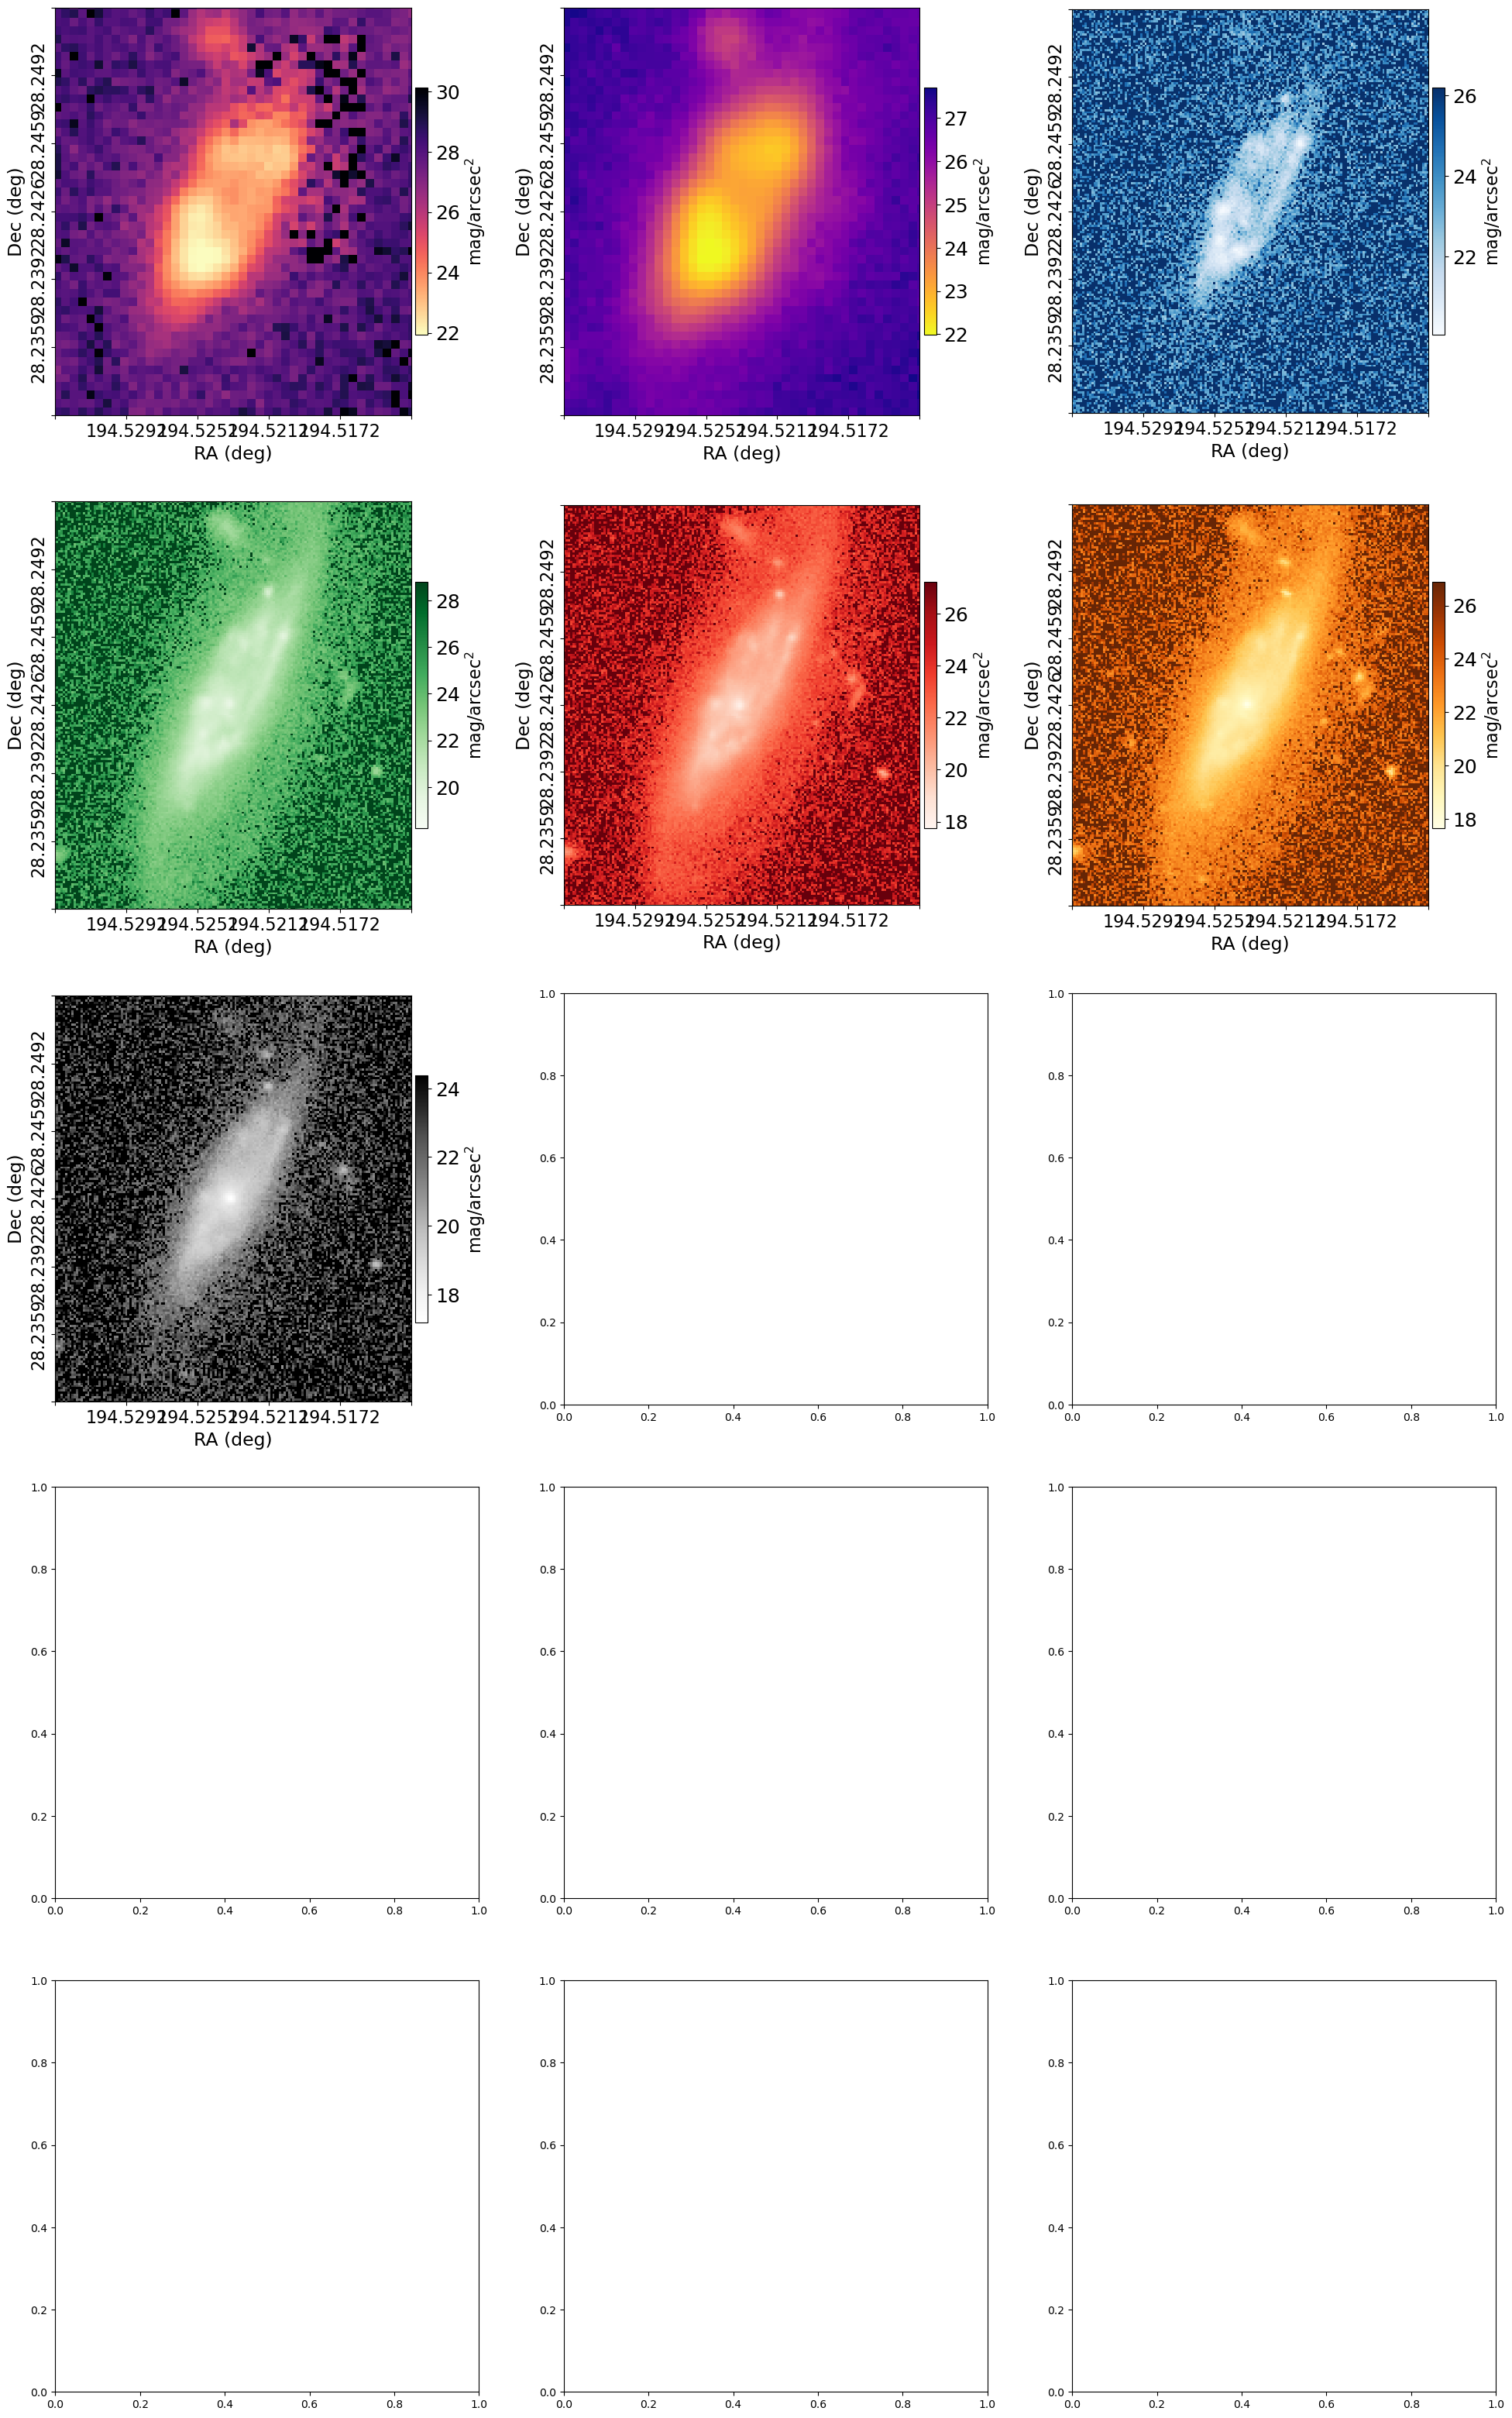

In [7]:
galaxy.plot( 
                
              # bands to plot. Can be just one
              # bands = 'galex_fuv',
              bands=['galex_fuv','galex_nuv','sdss_u','sdss_g','sdss_r','sdss_i','sdss_z','hst_wfc3_uvis_f350lp','spitzer_irac_1',
                     'spitzer_irac_2','spitzer_irac_3','spitzer_irac_4',
                     'herschel_pacs_70um','herschel_pacs_100um','herschel_pacs_160um'],
              
              plots_per_row=3, # Number of plots for each row
              #figsize= (10,5)  
              
              auto_titles=True,            # Enables automatic titles
              auto_titles_style=1,         # Style of autotitle. Can be 0 or 1
              auto_title_fontsize=20,      # Fontsize of autotitle
              auto_title_color='white',    # color of autotitle font

              axis_label_fontsize=17,
              axis_ticks_fontsize=16,
              cbar_label_fontsize=18,
              cbar_ticks_fontsize=16,
              n_xticks=4,

              ra_min = ra_center-0.01,
              ra_max = ra_center+0.01,
              dec_min = dec_center-0.01,
              dec_max = dec_center+0.01,

              set_cmaps = {'galex_nuv':'plasma',
                           'galex_fuv':'magma',
                           'spitzer_irac_1':'bone',
                           'spitzer_irac_2':'pink',
                           'spitzer_irac_3':'copper',
                           'spitzer_irac_4':'gist_heat',
                           'herschel_pacs_70um':'GnBu_r',
                           'herschel_pacs_100um':'YlGn_r',
                           'herschel_pacs_160um':'OrRd_r',
                          },
              
              set_scale_lims = {
                                'spitzer_irac_3':(1,10),
                                'spitzer_irac_4':(1,15),
                                'herschel_pacs_70um':(1,200),
                                'herschel_pacs_100um':(1,200),
                                'herschel_pacs_160um':(1,200),  
                               },         
            )



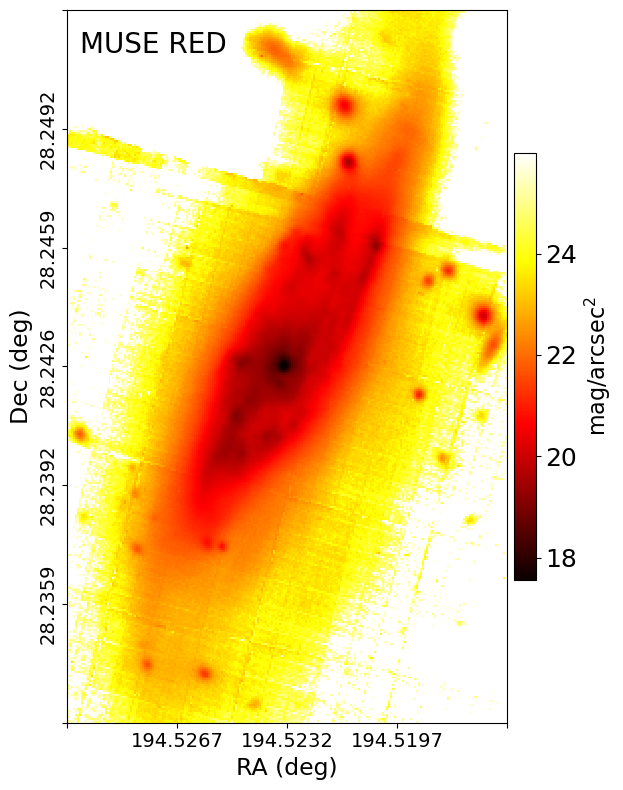

In [7]:
galaxy.plot( 
                
              # bands to plot. Can be just one
              bands = ['muse_red'],
              plots_per_row=1, # Number of plots for each row
              #figsize= (10,5)  
              
              auto_titles=True,            # Enables automatic titles
              auto_titles_style=0,         # Style of autotitle. Can be 0 or 1
              auto_title_fontsize=20,      # Fontsize of autotitle
              auto_title_color='black',    # color of autotitle font

              axis_label_fontsize=17,
              axis_ticks_fontsize=14,
              cbar_label_fontsize=18,
              cbar_ticks_fontsize=16,
              n_xticks=3,

              ra_min = ra_center-0.007,
              ra_max = ra_center+0.007,
              dec_min = dec_center-0.01,
              dec_max = dec_center+0.01,

              set_cmaps = {'muse_red':'hot_r'},

            )



In [6]:
galaxy.cubes.muse.line_map(line='Ha', width=10, continuum_offset_1=50, continuum_offset_2=50, z=z_true,pangal_object=galaxy);
galaxy.cubes.muse.line_map(line='Hb', width=10, continuum_offset_1=50, continuum_offset_2=50, z=z_true,pangal_object=galaxy);

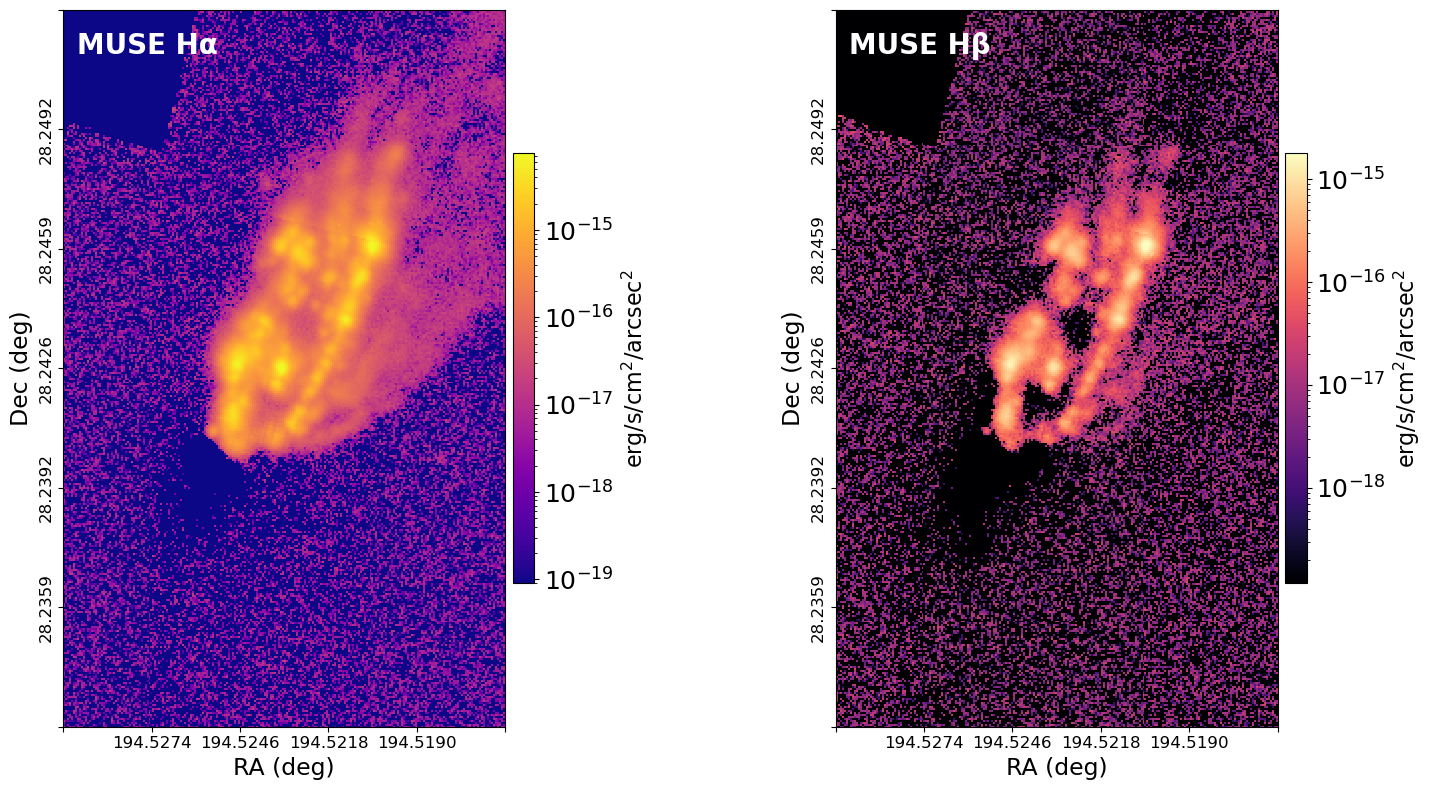

In [9]:
galaxy.plot( 
                
              # bands to plot. Can be just one
              # bands = 'galex_fuv',
              bands=['muse_Ha','muse_Hb'],
              
              plots_per_row=2, # Number of plots for each row
              #figsize= (10,5)  
              
              auto_titles=True,            # Enables automatic titles
              auto_titles_style=1,         # Style of autotitle. Can be 0 or 1
              auto_title_fontsize=20,      # Fontsize of autotitle
              auto_title_color='white',    # color of autotitle font

              axis_label_fontsize=17,
              axis_ticks_fontsize=12,
              cbar_label_fontsize=18,
              cbar_ticks_fontsize=16,
              n_xticks=4,

              ra_min = ra_center-0.007,
              ra_max = ra_center+0.007,
              dec_min = dec_center-0.01,
              dec_max = dec_center+0.01,

              set_units = {'muse_Ha':'erg_s_cm2_arcsec2','muse_Hb':'erg_s_cm2_arcsec2'},
              set_cmaps = {'muse_Ha':'plasma','muse_Hb':'magma',},
      
            )

In [6]:
# Define regions to mask stars
circles = []
for ra, dec in [[ra_center,dec_center]]:
    circles.append(
        Region.circle(
            ra_center=ra, dec_center=dec, radius=0.001,
            wcs=galaxy.images['muse_red'].wcs,
            image_shape=galaxy.images['muse_red'].mag_arcsec2.shape,
            linewidth=2, linestyle=':', color='purple'
        )
    )

# Define standard regions as ellipses
axis_ratio = 0.3
angle = 62

ellipses = []
for R in [10, 20, 3.23]:
    ellipses.append(
        Region.ellipse(
            ra_center=ra_center, dec_center=dec_center,
            semimajor_axis=R * theta_deg_1kpc,
            axis_ratio=axis_ratio, angle=angle,
            wcs=galaxy.images['muse_red'].wcs,
            image_shape=galaxy.images['muse_red'].mag_arcsec2.shape,
            linewidth=2, linestyle=':', color='gainsboro'
        )
    )

In [7]:
muse_obj = galaxy.images['muse_red']
npix_1kpc = theta_deg_1kpc / muse_obj.dtheta_pix_deg         # number of pixels corresponding to 1 kpc

image = muse_obj.erg_s_cm2_A

m_semimajor_ax = np.tan(angle*np.pi/180)
m_sep_line = -1/m_semimajor_ax

# REGIONS FOR MC-SPF
# Define the separator (regions must exclude Ha and Hb)

ra_x_p, dec_x_p = 194.5239703, 28.2387352
x_center, y_center = muse_obj.wcs.all_world2pix([[ra_center,dec_center]],1)[0] 

x_p, y_p = 114, 131
ra_x_p, dec_y_p = muse_obj.wcs.all_pix2world([[x_p, y_p]], 0)[0]

y_coords, x_coords = np.meshgrid(np.linspace(0, image.shape[0], image.shape[0]),np.linspace(0, image.shape[1], image.shape[1]),indexing='ij')
exclude_Ha_mask = (y_coords < m_sep_line * (x_coords - x_p) + y_p)
# REGIONS ARE DEFINED ON MUSE


regions_for_mcspf = []
from regions import EllipseAnnulusPixelRegion, PixCoord
from astropy import units as u

for i,r_kpc in enumerate(np.arange(6,18,3)):

    dr = 3
    region = EllipseAnnulusPixelRegion(
        center=PixCoord(x_center, y_center),
        inner_width = 2 * r_kpc * npix_1kpc, 
        outer_width = 2 * (r_kpc+dr) * npix_1kpc,  
        inner_height = axis_ratio * 2 * r_kpc * npix_1kpc,  
        outer_height = axis_ratio * 2 * (r_kpc+dr) * npix_1kpc,
        angle = angle*u.deg  
    )

    mask_elliptical_annulus = region.to_mask(mode='center').to_image(image.shape).astype(bool)
    mask = np.zeros_like(image, dtype=bool)
    mask |= (mask_elliptical_annulus & exclude_Ha_mask.astype(bool))


    if np.any(mask):

        R = r_kpc + dr/2
        print(R)
        x_centroid = x_center - R * npix_1kpc * np.cos(angle*np.pi/180)
        y_centroid = m_semimajor_ax * (x_centroid - x_center) + y_center 
        ra,dec = muse_obj.wcs.all_pix2world([[x_centroid, y_centroid]], 0)[0]

        regions_for_mcspf.append(Region(mask=mask,wcs=muse_obj.wcs,galactocentric_radius=R,caption_coords = [ra,dec],id=str(i+1))) 

for reg in regions_for_mcspf:
    reg.to_ds9('DATA/Coma/NGC4848/regions',append=True)
    

7.5
10.5
13.5
16.5
DS9 region file appended to: /home/utente/Desktop/Jellifish/DATA/Coma/NGC4848/regions.reg
DS9 region file appended to: /home/utente/Desktop/Jellifish/DATA/Coma/NGC4848/regions.reg
DS9 region file appended to: /home/utente/Desktop/Jellifish/DATA/Coma/NGC4848/regions.reg
DS9 region file appended to: /home/utente/Desktop/Jellifish/DATA/Coma/NGC4848/regions.reg


In [8]:
bands = ['galex_nuv','galex_fuv','sdss_u', 'sdss_g', 'sdss_r', 'sdss_i', 'sdss_z','spitzer_irac_1', 'spitzer_irac_2', 'spitzer_irac_3', 'spitzer_irac_4', 'herschel_pacs_70um', 'herschel_pacs_160um', 'herschel_pacs_100um']
#'wise_w1','wise_w2','wise_w3','wise_w4'
#'hst_wfc3_uvis_f350lp','hst_wfc3_uvis_f600lp'
phot_list = galaxy.photometry(regions_for_mcspf,background_exclude_regions=[ellipses[-1]],bands = bands,print_output=True)



GALEX NUV
Region 1: total flux: 1.00625, poisson unc: 0.00378, sky flux: 0.02999, sky std: 0.004081851195732284
	Flux = 0.03553 ± 0.00168 mJy, SNR = 21.21
Region 2: total flux: 0.80422, poisson unc: 0.00327, sky flux: 0.07051, sky std: 0.008759581933151933
	Flux = 0.02670 ± 0.00128 mJy, SNR = 20.92
Region 3: total flux: 0.51419, poisson unc: 0.00244, sky flux: 0.10566, sky std: 0.013172665706778918
	Flux = 0.01487 ± 0.00084 mJy, SNR = 17.68
Region 4: total flux: 0.42236, poisson unc: 0.00203, sky flux: 0.14095, sky std: 0.015983823526300848
	Flux = 0.01024 ± 0.00075 mJy, SNR = 13.61


GALEX FUV
Region 1: total flux: 0.18549, poisson unc: 0.00247, sky flux: 0.00289, sky std: 0.0011022927862672648
	Flux = 0.02105 ± 0.00102 mJy, SNR = 20.66
Region 2: total flux: 0.10954, poisson unc: 0.00185, sky flux: 0.00701, sky std: 0.002241678730437531
	Flux = 0.01182 ± 0.00064 mJy, SNR = 18.49
Region 3: total flux: 0.05220, poisson unc: 0.00118, sky flux: 0.01049, sky std: 0.003005903104366305
	Flux

In [10]:
phot_list[0].header

UNITS   = 'mJy     '                                                            

In [11]:
phot_list[0].print(phot_tables=phot_list,)

,Region 1,Region 2,Region 3,Region 4
Band,,,,
GALEX NUV,0.036 ± 0.002 (21.2),0.027 ± 0.001 (20.9),0.015 ± 0.001 (17.9),0.010 ± 0.001 (13.6)
GALEX FUV,0.021 ± 0.001 (20.7),0.012 ± 0.001 (18.7),0.005 ± 0.000 (10.9),0.003 ± 0.001 (6.0)
SDSS u,0.107 ± 0.008 (14.1),0.067 ± 0.010 (6.6),0.047 ± 0.016 (2.9),0.012 ± 0.027 (0.5)
SDSS g,0.362 ± 0.005 (73.5),0.264 ± 0.006 (43.5),0.168 ± 0.010 (17.5),0.118 ± 0.015 (8.1)
SDSS r,0.542 ± 0.007 (73.5),0.440 ± 0.011 (40.8),0.290 ± 0.016 (17.9),0.201 ± 0.023 (8.7)
SDSS i,0.671 ± 0.011 (63.0),0.578 ± 0.018 (31.7),0.403 ± 0.025 (16.0),0.275 ± 0.038 (7.3)
SDSS z,0.804 ± 0.029 (28.0),0.689 ± 0.061 (11.4),0.525 ± 0.068 (7.8),0.379 ± 0.097 (3.9)
IRAC Channel 1 (3.6 μm),0.486 ± 0.007 (66.2),0.468 ± 0.011 (41.2),0.364 ± 0.015 (23.9),0.267 ± 0.021 (12.9)
IRAC Channel 2 (4.5 μm),0.300 ± 0.006 (46.9),0.294 ± 0.013 (23.2),0.222 ± 0.018 (12.2),0.186 ± 0.024 (7.9)


In [10]:
phot_list[0].to_fits('DATA/Coma/NGC4848/new_photometry.dat')

Written 1 photometry table(s) to DATA/Coma/NGC4848/new_photometry.dat


In [11]:
ph = PhotometryTable()

In [14]:
ph.from_fits('DATA/Coma/NGC4848/new_photometry.dat')

ValueError: Extension PHOT_0 contains 14 rows. Each photometry table should contain exactly one row.

In [12]:
phot_list[0]

PhotometryTable(data={'galex_nuv': (0.03554053829510681, 0.001675851734014028), 'galex_fuv': (0.021038138238449685, 0.0010182813656176976), 'sdss_u': (0.10689184309349523, 0.007201831959744007), 'sdss_g': (0.36206486427202766, 0.004928893903557007), 'sdss_r': (0.5416541596040837, 0.007368633524489752), 'sdss_i': (0.6718012114634143, 0.009136951226979982), 'sdss_z': (0.8038376483676283, 0.027032472055316423), 'spitzer_irac_1': (0.48621804307104083, 0.006921476467544492), 'spitzer_irac_2': (0.29922541640100414, 0.00637165723361607), 'spitzer_irac_3': (0.28120250699578375, 0.025317629504642166), 'spitzer_irac_4': (0.32366087772573515, 0.023119408403428545), 'herschel_pacs_70um': (5.706142661052622, 0.6303566753942228), 'herschel_pacs_160um': (4.68057029674052, 0.24443032229146866), 'herschel_pacs_100um': (10.551967700225802, 0.7982572986193937)}, region=Region(header=, id='1', mask=array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, Fals

In [9]:
spectra = galaxy.cubes.muse.extract_spectra(regions=regions_for_mcspf,pangal_object=galaxy)

In [10]:
galaxy.spectra

{'muse_spec_1': Spectrum(wl=array([4750.14990234, 4751.39990234, 4752.64990234, ..., 8996.39990234,
        8997.64990234, 8998.89990234]), resolution=array([1638.10293994, 1638.73228303, 1639.36168271, ..., 3500.39457168,
        3500.68418529, 3500.9735422 ]), flux=array([5.2555917e-16, 5.1428151e-16, 5.2270790e-16, ..., 2.8949238e-16,
        2.7832780e-16, 2.5058782e-16], dtype=float32), flux_err=array([7.1417558e-18, 5.1764681e-18, 4.9664209e-18, ..., 1.6526691e-18,
        1.7546920e-18, 2.7261569e-18], dtype=float32), header={'SOURCE_ID': 'CUBE', 'REGION_ID': '1', 'NPIXELS': 861, 'FUNITS': 'erg/s/cm2/A', 'WUNITS': 'A'}),
 'muse_spec_2': Spectrum(wl=array([4750.14990234, 4751.39990234, 4752.64990234, ..., 8996.39990234,
        8997.64990234, 8998.89990234]), resolution=array([1638.10293994, 1638.73228303, 1639.36168271, ..., 3500.39457168,
        3500.68418529, 3500.9735422 ]), flux=array([4.0880311e-16, 3.6051244e-16, 3.8151875e-16, ..., 2.4864181e-16,
        2.1883824e-16, 1

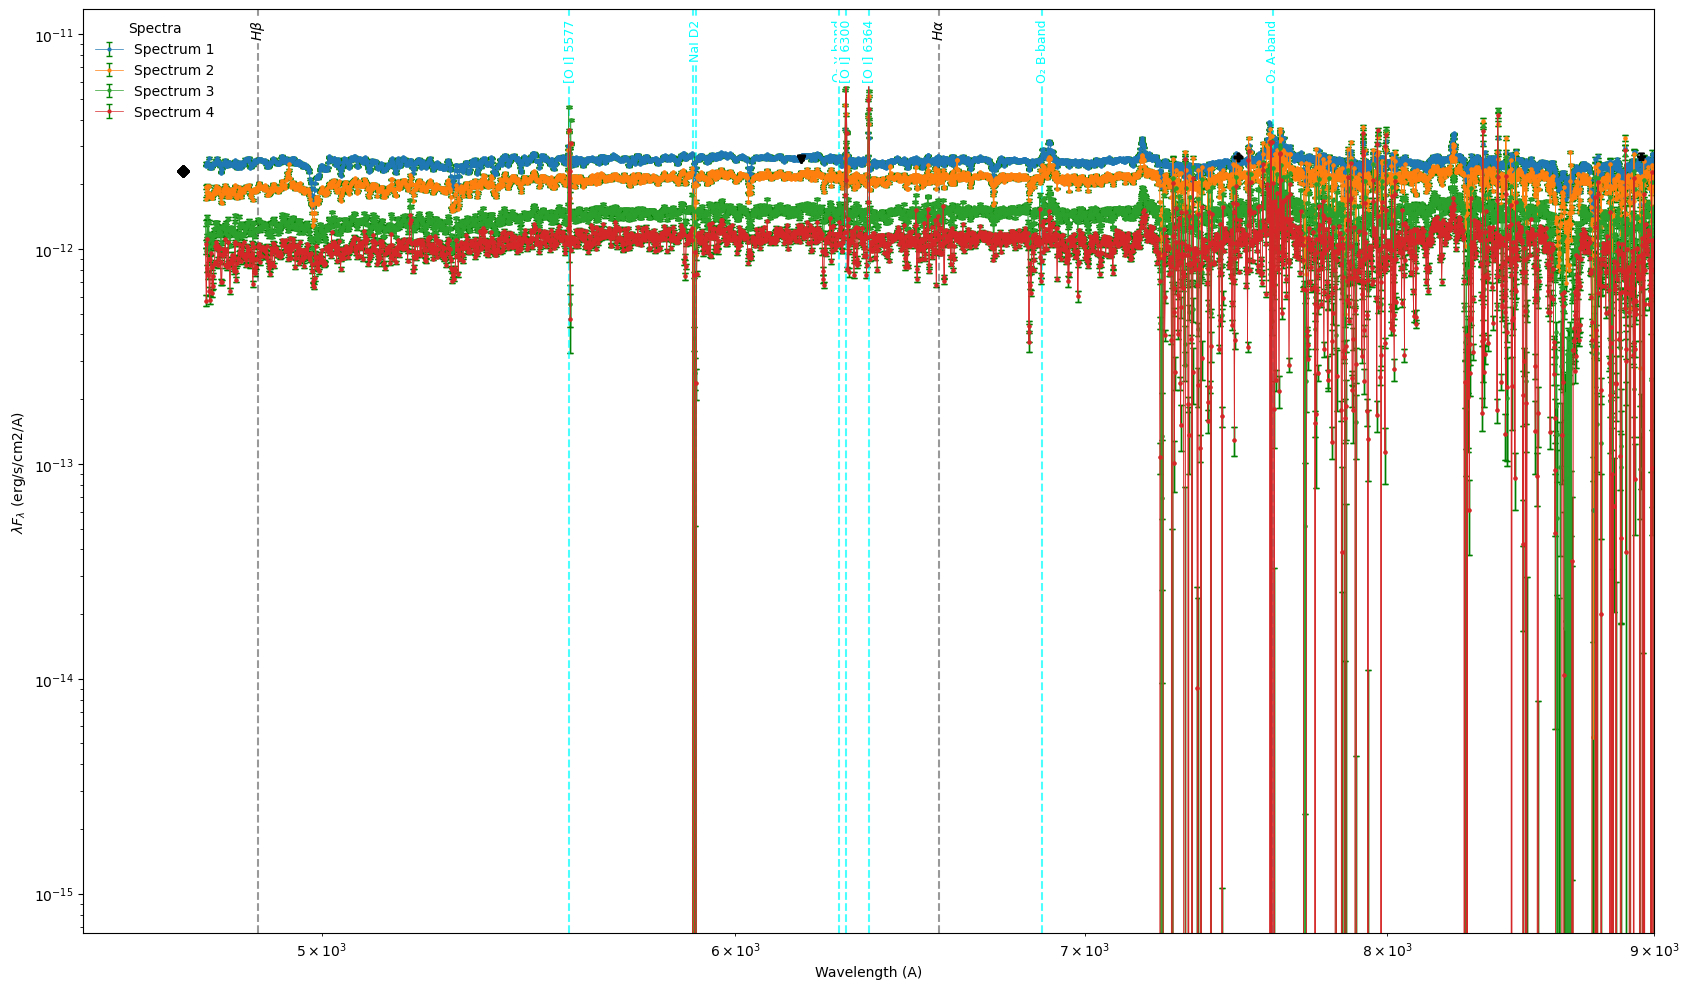

In [16]:

spectra[0].plot(figsize=(20,10),spectra=spectra,per_wavelength=True,phot_points=phot_list[0], #show_phot_legend=True,
              winf=4500,wsup=9000,show_H_lines=True,show_atmospheric_lines=True)
 #zoom_on_line=['Ha','Hb']



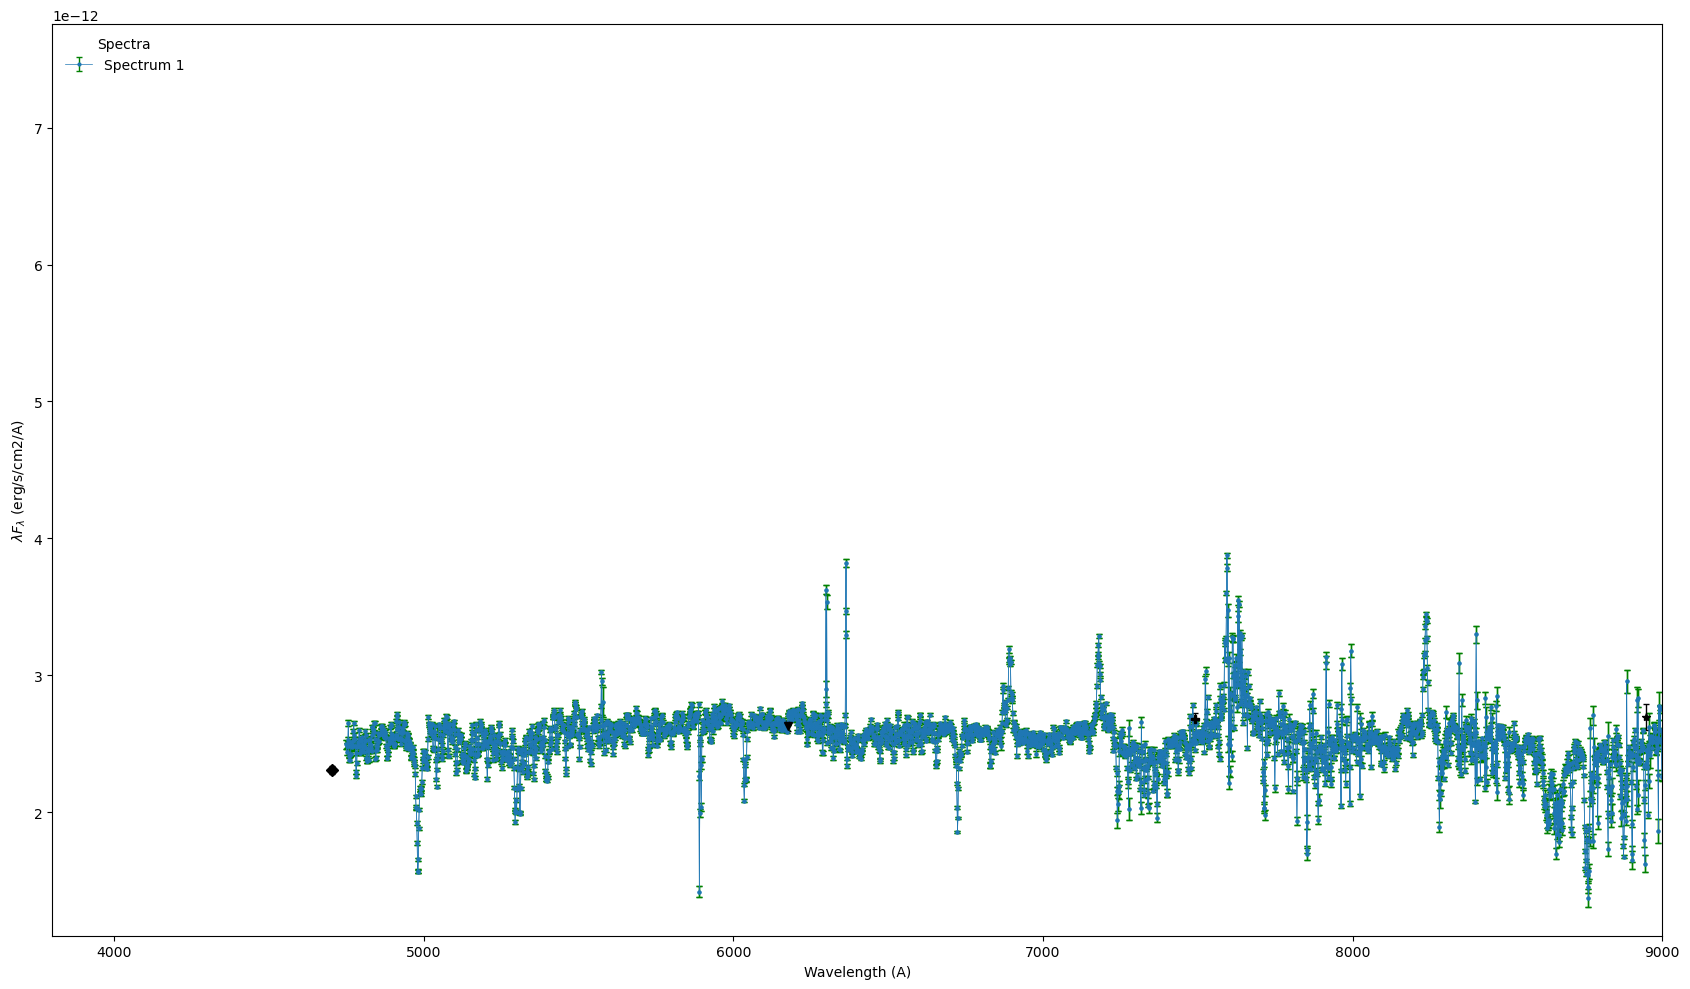

In [16]:

spectra[0].plot(figsize=(20,10),per_wavelength=True,show_phot_legend=True,phot_points=phot_list[0], #synth_phot_points=bands
              winf=3800,wsup=9000,log=False)  #spectra=spectra



In [10]:
spectra[0]

Spectrum(wl=array([4750.14990234, 4751.39990234, 4752.64990234, ..., 8996.39990234,
       8997.64990234, 8998.89990234]), resolution=array([1638.10293994, 1638.73228303, 1639.36168271, ..., 3500.39457168,
       3500.68418529, 3500.9735422 ]), flux=array([5.2555917e-16, 5.1428151e-16, 5.2270790e-16, ..., 2.8949238e-16,
       2.7832780e-16, 2.5058782e-16], dtype=float32), flux_err=array([7.1417558e-18, 5.1764681e-18, 4.9664209e-18, ..., 1.6526691e-18,
       1.7546920e-18, 2.7261569e-18], dtype=float32), header={'SOURCE_ID': 'CUBE', 'REGION_ID': '1', 'NPIXELS': 861, 'FUNITS': 'erg/s/cm2/A', 'WUNITS': 'A'})

In [10]:
from build_boissier import truncated_boissier_sfh, truncated_boissier_sed, build_boissier_SEDs, load_spectrum_models_from_fits


from pangal.pfitter import PFitter


In [11]:
model_specs = load_spectrum_models_from_fits(filename='V_160_R_7.fit')

In [12]:


fitter = PFitter(model_specs,
                 model_pars=['Q_AGE','TAU_Q','BURST','METAL'],
                )



Initializing PFitter object
   Model parameters: Q_AGE, TAU_Q, BURST, METAL

 Pre-computed model grid:
   - Q_AGE: 19 values, min=10, max=1000
   - TAU_Q: 15 values, min=2, max=1000
   - BURST: 6 values, min=0.0, max=100.0
   - METAL: 5 values, min=0.008, max=0.03


Loading nebular lines templates from  nebular_Byler_mist_2018.lines
 Emission line metallicity requested 0.0017, found 0.0020
Tabulated values for ionized gas age (Myr): [ 0.5  1.   2.   3.   4.   5.   6.   7.  10. ]
Tabulated values for ionization coefficient: [-4.  -3.5 -3.  -2.5 -2.  -1.5 -1. ]
Loading of nebular lines templates completed.
Tabulated alpha values from 'alpha_dh02.dat': [0.0625 0.125  0.1875 0.25   0.3125 0.375  0.4375 0.5    0.5625 0.625
 0.6875 0.75   0.8125 0.875  0.9375 1.     1.0625 1.125  1.1875 1.25
 1.3125 1.375  1.4375 1.5    1.5625 1.625  1.6875 1.75   1.8125 1.875
 1.9375 2.     2.0625 2.125  2.1875 2.25   2.3125 2.375  2.4375 2.5
 2.5625 2.625  2.6875 2.75   2.8125 2.875  2.9375 3.     3.0625 3

In [13]:

custom_prior = {
    'av':     {'type':'uniform', 'low':0.0,    'high':0.2},
    'alpha':  {'type':'uniform', 'low':1.5,    'high':3.5},
    'm_star':  {'type':'uniform', 'low':9,    'high':9.5},
    'sigma_vel': {'type':'uniform', 'low':200,    'high':400},
    'vel_sys': {'type':'uniform', 'low':-325,    'high':-320},
}


In [18]:
results = fitter.run_fit(phot=phot_list[0], 
                         bands=bands, 
                         spec=spectra[0],
                         fix_pars={'ion_gas':-3.94,'age_gas':13,'fesc':1.,'BURST':0,'METAL':0.017,},
                         nlive=100,
                         dlogz=0.1,
                         spectral_range=[5000,7000],
                         custom_priors=custom_prior,
                         )


Using the following photometric filters: galex_nuv, galex_fuv, sdss_u, sdss_g, sdss_r, sdss_i, sdss_z, spitzer_irac_1, spitzer_irac_2, spitzer_irac_3, spitzer_irac_4, herschel_pacs_70um, herschel_pacs_160um, herschel_pacs_100um
Redshift not provided; set to 0.

Priors:
  - Q_AGE: Uniform(10, 1000)
  - TAU_Q: Uniform(2, 1000)
  - av: Uniform(0.0, 0.2)
  - av_ext: Uniform(0.0, 1.0)
  - alpha: Uniform(1.5, 3.5)
  - m_star: Uniform(9, 9.5)
  - vel_sys: Uniform(-325, -320)
  - sigma_vel: Uniform(200, 400)
Initializing live points
Exception while calling loglikelihood function:
  params: [ 5.88192861e+02  4.14163879e+02  1.15717826e-01  3.02070771e-01
  1.94235653e+00  9.07316252e+00 -3.22493169e+02  3.87007488e+02]
  args: []
  kwargs: {}
  exception:


Traceback (most recent call last):
  File "/home/utente/anaconda3/envs/cigale/lib/python3.11/site-packages/dynesty/dynesty.py", line 913, in __call__
    return self.func(np.asarray(x).copy(), *self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/utente/Desktop/Pangal/pangal/pfitter.py", line 281, in log_likelihood
    run.fix_pars.setdefault("vel_sys", None)
                                 ^^^^^^^^^
IndexError: index 8 is out of bounds for axis 0 with size 8


╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:1                                                                                    │
│                                                                                                  │
│ ❱  1 results = fitter.run_fit(phot=phot_list[0],                                                 │
│    2 │   │   │   │   │   │    bands=bands,                                                       │
│    3 │   │   │   │   │   │    spec=spectra[0],                                                   │
│    4 │   │   │   │   │   │    fix_pars={'ion_gas':-3.94,'age_gas':13,'fesc':1.,'BURST':0,'MET    │
│                                                                                                  │
│ /home/utente/Desktop/Pangal/pangal/pfitter.py:223 in run_fit                                     │
│                                                                                                  │
│   220 │   │   │   bands=None,                                                                    │
│   221 │   │   │   spectral_range=None,                                                           │
│   222 │   │   │   fix_pars=None,                                                                 │
│ ❱ 223 │   │   │   custom_priors=None,                                                            │
│   224 │   │   │   polymax=7,                                                                     │
│   225 │   │   │   nlive=500,                                                                     │
│   226 │   │   │   dlogz=0.01):                                                                   │
│                                                                                                  │
│ /home/utente/anaconda3/envs/cigale/lib/python3.11/site-packages/dynesty/dynesty.py:680 in        │
│ __new__                                                                                          │
│                                                                                                  │
│   677 │   │   │   kwargs['grad'] = grad                                                          │
│   678 │   │   │   kwargs['compute_jac'] = compute_jac                                            │
│   679 │   │                                                                                      │
│ ❱ 680 │   │   live_points, logvol_init, init_ncalls = _initialize_live_points(                   │
│   681 │   │   │   live_points,                                                                   │
│   682 │   │   │   ptform,                                                                        │
│   683 │   │   │   loglike,                                                                       │
│                                                                                                  │
│ /home/utente/anaconda3/envs/cigale/lib/python3.11/site-packages/dynesty/dynamicsampler.py:438 in │
│ _initialize_live_points                                                                          │
│                                                                                                  │
│    435 │   │   │   else:                                                                         │
│    436 │   │   │   │   cur_live_v = map(prior_transform, np.asarray(cur_live_u))                 │
│    437 │   │   │   cur_live_v = np.array(list(cur_live_v))                                       │
│ ❱  438 │   │   │   cur_live_logl = loglikelihood.map(np.asarray(cur_live_v))                     │
│    439 │   │   │   if blob:                                                                      │
│    440 │   │   │   │   cur_live_blobs = np.array([_.blob for _ in cur_live_logl])                │
│    441 │   │   │   cur_live_logl = np.array([_.val for _ in cur_live_logl])                      │
│                                                            

In [16]:
results.

In [15]:
fitter.cornerplot(results)

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:1                                                                                    │
│                                                                                                  │
│ ❱ 1 fitter.cornerplot(results)                                                                   │
│   2                                                                                              │
│                                                                                                  │
│ /home/utente/Desktop/Pangal/pangal/pfitter.py:805 in cornerplot                                  │
│                                                                                                  │
│   802 │   │   │   Transparency for 2D contour fills.                                             │
│   803 │   │   """                                                                                │
│   804 │   │   #resample                                                                          │
│ ❱ 805 │   │   samples, weights = fit_result.samples, np.exp(fit_result.logwt - fit_result.logz   │
│   806 │   │   equal_samples = resample_equal(samples, weights)                                   │
│   807 │   │                                                                                      │
│   808 │   │   # Map parameter names to nicer LaTeX labels                                        │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
AttributeError: 'Run' object has no attribute 'samples'

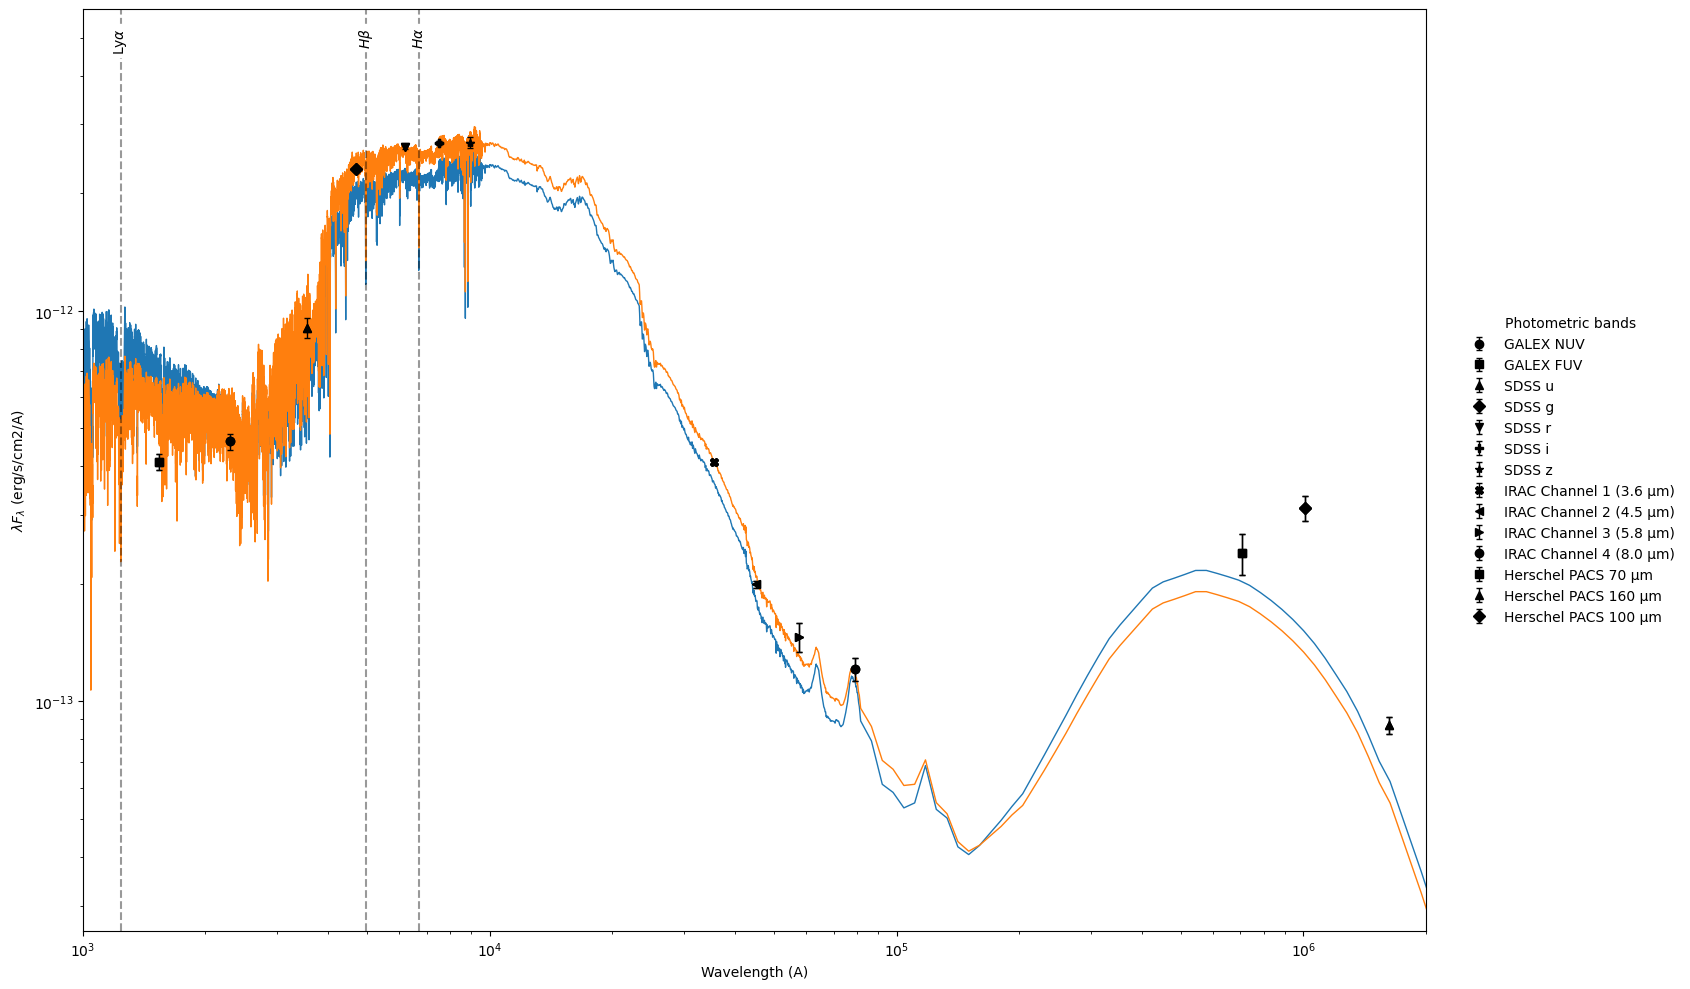

In [32]:
fit_spec_1.plot(figsize=(20,10),spectra=[fit_spec_1,fit_spec_2],per_wavelength=True,phot_points=phot_list[0],phot_legend=True,
              winf=1000,wsup=2e6,show_H_lines=True,log=True)

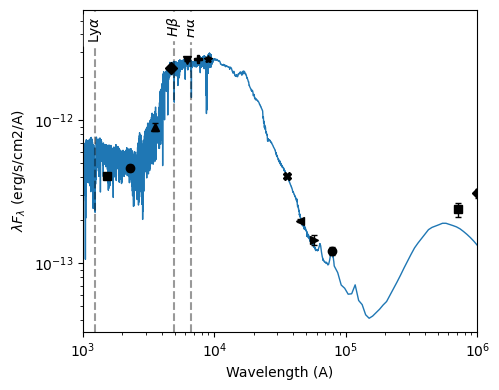

In [36]:
fit_spec_1.plot(spectra=[fit_spec_2],per_wavelength=True,phot_points=phot_list[0],phot_legend=False,
              winf=1000,wsup=1e6,show_H_lines=True,log=True)

In [34]:
fit_spec = fitter.synthetic_spectrum(
            multi_component=True,
            Q_AGE=900,
            TAU_Q=500,
            BURST=0,
            METAL=0.013,
            fesc=1.,
            av=0.05,
            av_ext= 0.05,
            alpha=1.6,
            m_star=9.34,
            ion_gas=-3.94,
            age_gas=13,
            redshift=0.023974,
            vel_sys = +200.9,
            sigma_vel = 66,
            dl=104,  # Luminosity distance in Mpc (assumed)
            
        )



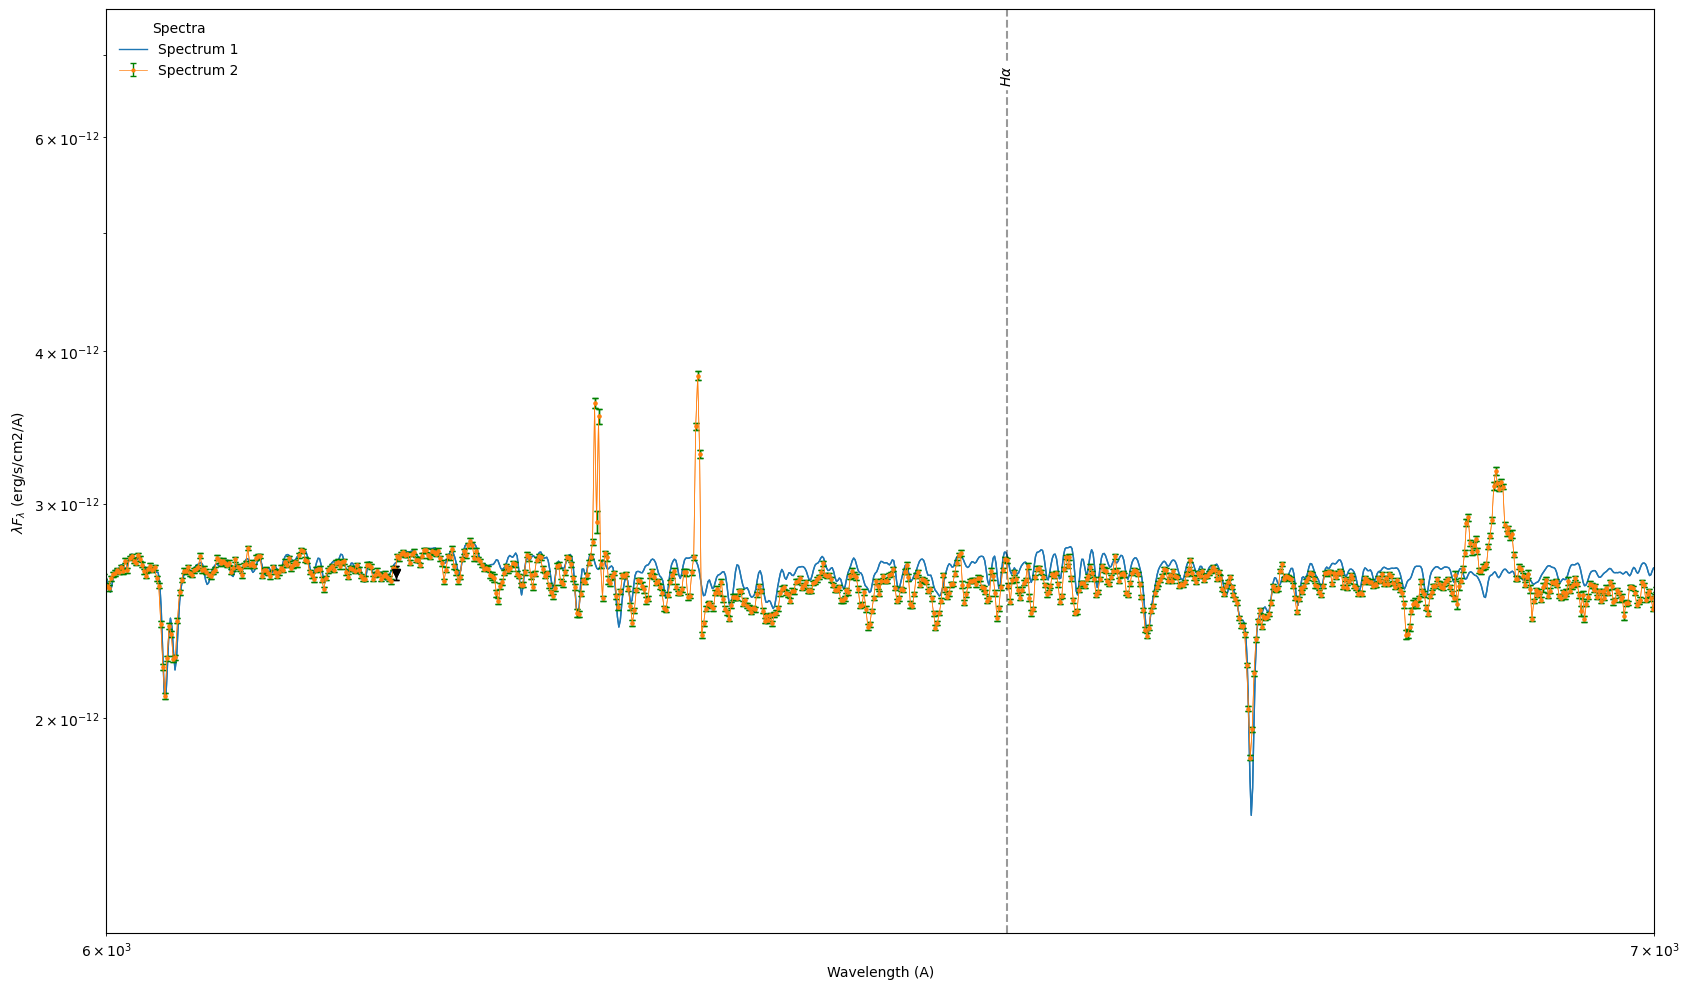

In [35]:
fit_spec.plot(figsize=(20,10),spectra=[fit_spec,spectra[0]],per_wavelength=True,phot_points=phot_list[0],show_phot_legend=True,
              winf=6000,wsup=7000,show_H_lines=True,log=True)



In [54]:
spectra[0].resolution

array([1638.10293994, 1638.73228303, 1639.36168271, ..., 3500.39457168,
       3500.68418529, 3500.9735422 ])

In [55]:
spectra[0].res_delta_lambda

array([2.89978718, 2.89943632, 2.89908563, ..., 2.57011023, 2.57025468,
       2.57039929])